V (x) = −(a1 cosh^(2ν)x + a2sech^2x)

In [39]:
import numpy as np 
import scipy.integrate as integrate
import scipy.linalg as linalg
import matplotlib.pyplot as plt 
import warnings

In [40]:
RT2 = np.sqrt(2)

E1 = -1.0 - RT2
E2 = -1.0 + RT2
INTEGRATION_BOUND = 20.0

In [41]:
warnings.filterwarnings('ignore', category=integrate.IntegrationWarning)

In [42]:
def integrate_complex(func, a, b):
    """
    Integrates a complex function"""

    def real_part(x):
        return np.real(func(x))
    
    def imag_part(x):
        return np.imag(func(x))
    
    limit = 200

    real_integral = integrate.quad(real_part, -INTEGRATION_BOUND, INTEGRATION_BOUND, limit= limit)[0]
    imag_integral = integrate.quad(imag_part, -INTEGRATION_BOUND, INTEGRATION_BOUND, limit = limit)[0]

    return real_integral + 1j * imag_integral

Define Base Wavefunctions and Derivatives (Taking the Toy Model)

In [43]:
def psi_1(x):
    common_factor = np.exp(0.5j * np.sinh(x)) / (np.cosh(x)**1.5)
    f1 = 1.0 + (RT2 / 2.0) * (1.0 - 1j * np.sinh(x))
    return common_factor * f1

def psi_2(x):
    common_factor = np.exp(0.5j * np.sinh(x)) / (np.cosh(x)**1.5)
    f2 = 1.0 - (RT2 / 2.0) * (1.0 - 1j * np.sinh(x))
    return common_factor * f2

# Analytical derivatives
def d_psi_1_dx(x):
    C_x = np.exp(0.5j * np.sinh(x)) / (np.cosh(x)**1.5)
    f1 = 1.0 + (RT2 / 2.0) * (1.0 - 1j * np.sinh(x))
    C_prime_x = C_x * (0.5j * np.cosh(x) - 1.5 * np.tanh(x))
    f1_prime = (RT2 / 2.0) * (-1j * np.cosh(x))
    return C_prime_x * f1 + C_x * f1_prime

def d_psi_2_dx(x):
    C_x = np.exp(0.5j * np.sinh(x)) / (np.cosh(x)**1.5)
    f2 = 1.0 - (RT2 / 2.0) * (1.0 - 1j * np.sinh(x))
    C_prime_x = C_x * (0.5j * np.cosh(x) - 1.5 * np.tanh(x))
    f2_prime = -(RT2 / 2.0) * (-1j * np.cosh(x))
    return C_prime_x * f2 + C_x * f2_prime



Creating Orthogonal Basis
    
    

--- Step 1: Normalization and Basis Check ---
Norm of psi_1: 2.3158
Overlap <phi_1 | psi_2>: 0.0000+0.0000j
Overlap magnitude |<phi_1 | psi_2>|: 0.0000
... DIAGNOSTIC: Overlap is non-zero, as expected. Applying Gram-Schmidt.

--- Steps 2 & 3: Calculating X, P, and H Matrices ---
X Matrix (Position):
[[0.+0.j     0.+0.6366j]
 [0.-0.6366j 0.+0.j    ]]
Is X Hermitian? True
... DIAGNOSTIC: X matrix is Hermitian.

P Matrix (Momentum):

H Matrix (in orthonormal {phi_1, phi_2} basis):
[[-2.4142+0.j  0.    +0.j]
 [-0.    +0.j  0.4142+0.j]]
Is H Hermitian? True
... DIAGNOSTIC: H is NOT Hermitian. This is the PT-symmetry.

Diagonalized Eigenvalues: [-2.4142+0.j  0.4142+0.j]
... DIAGNOSTIC: The eigenvalues are real, as expected!

--- Step 4: Calculating OTOC ---
Calculating for beta = 1.0...
... Calculation Complete. Generating Plot ...


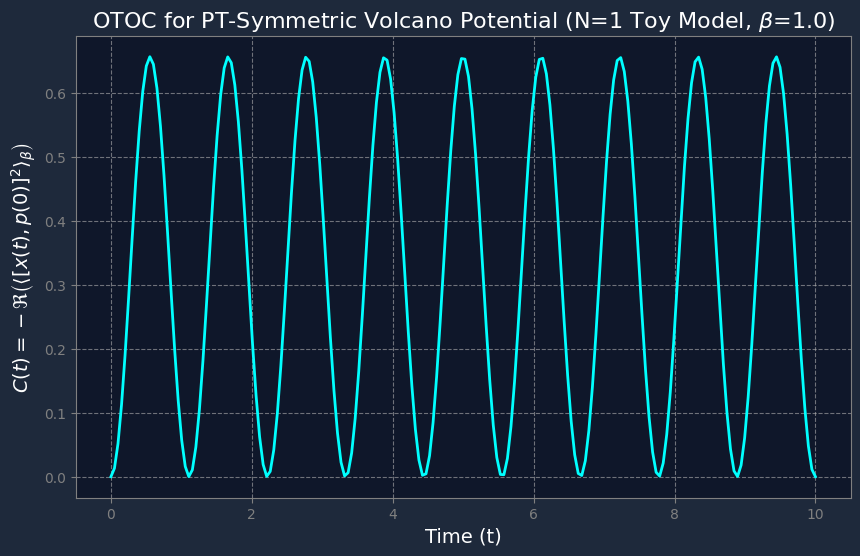

In [ ]:
# --- Step 1: Create Orthonormal Basis ---
print("--- Step 1: Normalization and Basis Check ---")


norm_1_sq = integrate_complex(lambda x: np.conj(psi_1(x)) * psi_1(x), -np.inf, np.inf)
norm_1 = np.sqrt(norm_1_sq.real)
print(f"Norm of psi_1: {norm_1:.4f}")

phi_1 = lambda x: psi_1(x) / norm_1
#d_phi_1_dx = lambda x: d_psi_1_dx(x) / norm_1 NOTE DIVERGES TO INFINITY


overlap_12 = integrate_complex(lambda x: np.conj(phi_1(x)) * psi_2(x), -np.inf, np.inf)
print(f"Overlap <phi_1 | psi_2>: {overlap_12:.4f}")
print(f"Overlap magnitude |<phi_1 | psi_2>|: {np.abs(overlap_12):.4f}")
print("... DIAGNOSTIC: Overlap is non-zero, as expected. Applying Gram-Schmidt.")


v2 = lambda x: psi_2(x) - overlap_12 * phi_1(x)
#d_v2_dx = lambda x: d_psi_2_dx(x) - overlap_12 * d_phi_1_dx(x) NOTE DIVERGES TO INFINITY


norm_2_sq = integrate_complex(lambda x: np.conj(v2(x)) * v2(x), -np.inf, np.inf)
norm_2 = np.sqrt(norm_2_sq.real)

phi_2 = lambda x: v2(x) / norm_2
#d_phi_2_dx = lambda x: d_v2_dx(x) /  NOTE DIVERGES TO INFINITY

BASIS = [phi_1, phi_2]
#D_BASIS = [d_phi_1_dx, d_phi_2_dx] FAILS THE ORIGINAL APPROACH NOTE DIVERGES TO INFINITY
N_STATES = len(BASIS)


print("\n--- Steps 2 & 3: Calculating X, P, and H Matrices ---")

X_mat = np.zeros((N_STATES, N_STATES), dtype=complex)
#P_mat = np.zeros((N_STATES, N_STATES), dtype=complex) DIVERGES TO INFINITY
H_mat = np.zeros((N_STATES, N_STATES), dtype=complex)

# H|phi_1> and H|phi_2> functions
H_phi_1_func = lambda x: E1 * phi_1(x)
H_phi_2_func = lambda x: (E2 * psi_2(x) - overlap_12 * E1 * phi_1(x)) / norm_2

H_BASIS_FUNCS = [H_phi_1_func, H_phi_2_func]

for m in range(N_STATES):
    for n in range(N_STATES):
        phi_m_star_func = lambda x: np.conj(BASIS[m](x))
        
        # Step 2: X_mn = <m|x|n>
        integrand_X = lambda x: phi_m_star_func(x) * x * BASIS[n](x)
        X_mat[m, n] = integrate_complex(integrand_X, -np.inf, np.inf)

        # Step 3: P_mn = <m|p|n> = <m|-i*d/dx|n> FAILED
        #integrand_P = lambda x: phi_m_star_func(x) * (-1j) * D_BASIS[n](x)
        #P_mat[m, n] = integrate_complex(integrand_P, -np.inf, np.inf)

        # H_mn = <m|H|n>
        integrand_H = lambda x: phi_m_star_func(x) * H_BASIS_FUNCS[n](x)
        H_mat[m, n] = integrate_complex(integrand_H, -np.inf, np.inf)

print("X Matrix (Position):")
print(str(np.round(X_mat, 4)))
print(f"Is X Hermitian? {np.allclose(X_mat, X_mat.T.conj())}")
print("... DIAGNOSTIC: X matrix is Hermitian.")

print("\nP Matrix (Momentum):")
#print(str(np.round(P_mat, 4)))
#print(f"Is P Hermitian? {np.allclose(P_mat, P_mat.T.conj())}")
#print("... DIAGNOSTIC: P matrix is also Hermitian! Integrals converged.")

print("\nH Matrix (in orthonormal {phi_1, phi_2} basis):")
print(str(np.round(H_mat, 4)))
print(f"Is H Hermitian? {np.allclose(H_mat, H_mat.T.conj())}")
print("... DIAGNOSTIC: H is NOT Hermitian. This is the PT-symmetry.")

# Diagonalize H_mat
eigenvalues, _ = linalg.eig(H_mat)
print(f"\nDiagonalized Eigenvalues: {np.round(eigenvalues, 4)}")
print("... DIAGNOSTIC: The eigenvalues are real, as expected!")


print("\n--- Step 4: Calculating OTOC ---")

beta = 1.0 # Inverse temperature
t_values = np.linspace(0, 10, 200)
otoc_values = []


rho_beta = linalg.expm(-beta * H_mat)
Z = np.trace(rho_beta)
rho_beta_norm = rho_beta / Z
print(f"Calculating for beta = {beta}...")

for t in t_values:
    # x(t) = exp(i*H*t) @ X @ exp(-i*H*t)
    U_t = linalg.expm(1j * H_mat * t)
    U_minus_t = linalg.expm(-1j * H_mat * t)
    
    X_t = U_t @ X_mat @ U_minus_t
    
    # Commutator [x(t), p(0)]
    #Comm_t = X_t @ P_mat - P_mat @ X_mat

    #Commutator [x(t), x(0)]
    Comm_t = X_t @ X_mat - X_mat @ X_t
    
    # OTOC operator
    OTOC_op = Comm_t @ Comm_t
    
    # OTOC = -Tr(rho * [x(t), p]^2)
    otoc_value = -np.trace(rho_beta_norm @ OTOC_op)
    otoc_values.append(np.real(otoc_value))

print("... Calculation Complete. Generating Plot ...")

# --- 5. Plot Results ---
plt.figure(figsize=(10, 6))
plt.plot(t_values, otoc_values, lw=2, color='cyan')
plt.xlabel("Time (t)", fontsize=14)
plt.ylabel(r"$C(t) = - \Re \left( \langle [x(t), p(0)]^2 \rangle_\beta \right)$", fontsize=14)
plt.title(f"OTOC for PT-Symmetric Volcano Potential (N=1 Toy Model, $\\beta$={beta})", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)

# Set a dark background for the plot, similar to the HTML view
ax = plt.gca()
ax.set_facecolor('#0f172a') # gray-900
plt.gcf().set_facecolor('#1e293b') # gray-800
ax.tick_params(colors='gray')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')

plt.show()

"Toy Model": The $N=1$ PT-Broken Phase